In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

torch.manual_seed(42)

In [3]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [4]:
import kagglehub
import shutil
import os

# Download dataset
path = kagglehub.dataset_download("sachinkumar413/diabetic-retinopathy-dataset")
print("Downloaded to:", path)

# Copy to local folder
destination = "./dataset"

shutil.copytree(path, destination, dirs_exist_ok=True)
print("Copied to:", destination)

# Check structure
for root, dirs, files in os.walk(destination):
    print("Current path:", root)
    print("Folders:", dirs)
    print("------")
    break

# Remove unwanted folders
folders_to_remove = ["Mild DR", "Moderate DR", "Proliferate DR"]

for folder in folders_to_remove:
    folder_path = os.path.join(destination, folder)

    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"Removed: {folder_path}")
    else:
        print(f"Folder not found: {folder_path}")

C:\Users\Innam\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: C:\Users\Innam\.cache\kagglehub\datasets\sachinkumar413\diabetic-retinopathy-dataset\versions\1
Copied to: ./dataset
Current path: ./dataset
Folders: ['Healthy', 'Mild DR', 'Moderate DR', 'Proliferate DR', 'Severe DR']
------
Removed: ./dataset\Mild DR
Removed: ./dataset\Moderate DR
Removed: ./dataset\Proliferate DR


In [5]:
complete_path = "./dataset/.complete"

if os.path.exists(complete_path):
    shutil.rmtree(complete_path)
    print("Removed .complete folder")

In [6]:
# For loading the Diabetic Retinopathy Dataset

transforms_base = transforms.Compose([transforms.ToTensor()])

# full_dataset[i] is a a tuple of (image tensor, class index)
full_dataset = torchvision.datasets.DatasetFolder(root="./dataset", loader=torchvision.datasets.folder.default_loader, transform=transforms_base, extensions=[".png"])

In [7]:
print("Classes:", full_dataset.class_to_idx)
print("Total dataset size:", len(full_dataset))

healthy = 0
severe = 0
for data in full_dataset:
    if data[1] == 0:
        healthy += 1
    elif data[1] == 1:
        severe += 1
print("Total 'Healthy' samples:", healthy)
print("Total 'Severe' samples:", severe)

Classes: {'Healthy': 0, 'Severe DR': 1}
Total dataset size: 1190
Total 'Healthy' samples: 1000
Total 'Severe' samples: 190


In [8]:
'''
Training-Test-Validation Split
Train dataset: 80% of 'Healthy' + 80% of 'Severe'
Test dataset: 10% of 'Healthy' + 10% of 'Severe'
Validation dataset: 10% of 'Healthy' + 10% of 'Severe'
'''

targets = full_dataset.targets
train_indices = []
test_indices = []
validation_indices = []

for c in range(len(full_dataset.classes)):
    class_indices = [i for i, t in enumerate(targets) if t==c]
    torch.manual_seed(42)
    perm = torch.randperm(len(class_indices)).tolist()
    if c == 0:
        r = healthy
    else:
        r = severe
    a = int(r*0.8)
    b = int(r*0.9)
    train_indices.extend([class_indices[p] for p in perm[:a]])
    test_indices.extend([class_indices[p] for p in perm[a:b]])
    validation_indices.extend([class_indices[p] for p in perm[b:r]])

train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
test_dataset = torch.utils.data.Subset(full_dataset, test_indices)
validation_dataset = torch.utils.data.Subset(full_dataset, validation_indices)

In [9]:
# Dataloaders
torch.manual_seed(42)
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size, shuffle=False)
validation_dataloader = DataLoader(validation_dataset, batch_size, shuffle=False)

In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        # Two Conv2d layers with ReLU
        self.conv = nn.Sequential(nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                                  nn.BatchNorm2d(out_c),
                                  nn.ReLU(),
                                  nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                                  nn.BatchNorm2d(out_c),
                                  nn.ReLU()
                                  )
    def forward(self, x):
        return self.conv(x)


In [11]:
class EncoderBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()

        # Encoder: Conv block followed by MaxPool to downsample
        self.conv = ConvBlock(in_c, out_c)
        self.pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        # skip connection output before pooling
        s = self.conv(x)
        p = self.pool(s)
        return s, p


In [12]:
class DecoderBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        # Decoder: ConvTranspose2d to upsample (deconvolution), then Conv block
        self.up = nn.Sequential(
            nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
        )
        # After upsampling, concatenate skip connection by doubbling then conv
        self.conv = ConvBlock(out_c * 2, out_c)


    def forward(self, x, skip, attn):
        #first upsample, then concatenate skip connection then conv
        x = self.up(x)
        skip = skip*attn
        x = torch.cat([x, skip], dim=1)
        x = self.conv(x)
        return x

In [ ]:
def save_image(output, dir, type, batch=0, epoch=0):
    '''
    Saves images from tensor outputs to help showcase the image segmentation/attention
    Inputs: 
        - output: Tensor of N*C*H*W
        - dir: string of folder/dir to save images at 
        - type: string (standardised to either 'attn' or 'out')
        - batch: batch number of images
        - epoch: particular epoch
    '''
    n = output.shape[0]
    out = output.detach().cpu()

    if epoch == 0 or epoch == 19:
        # Creates epoch folder
        full_dir = "{}/{}".format(dir,epoch)
        if not os.path.exists(full_dir):
            os.makedirs(full_dir)

        for i in range(n):
            if (type == "attn"):
                flattened_output = torch.mean(out[i], dim=0, keepdim=True) # From C*H*W to 1*H*W Grayscale image
                image = torchvision.transforms.functional.to_pil_image(flattened_output, mode="L")
                del flattened_output
            else:
                image = torchvision.transforms.functional.to_pil_image(out[i], mode="LA")
            filepath = "{}/{}{}.png".format(full_dir, type, str(i+batch*n)) # E.g. "./attn/attn20.png"
            image.save(filepath)

            # Helps to resolve memory issues by clearing these temporary outputs
            del image
            torch.cuda.empty_cache()

    del out

In [14]:
class AttentionGate(nn.Module):
    '''
    Attention Gates (AG) filter out features passed through skip connections
    '''
    def __init__(self, x_in_c, g_in_c, out_c):
        super().__init__()
        self.Wx_T = nn.Conv2d(x_in_c, out_c, kernel_size=1, stride=2) # x has lower amt of channels but higher resolution; requires stride of 2 to downsample
        self.Wg_T = nn.Conv2d(g_in_c, out_c, kernel_size=1, stride=1)
        self.psi = nn.ConvTranspose2d(out_c, out_c, kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, g):
        '''
        x: skip connection
        g: gating signal
        '''

        # Projection so that x & g their feature resolutions match
        x_out = self.Wx_T(x)
        g_out = self.Wg_T(g)

        # Calculate the additive attention
        q = self.psi(self.relu(x_out + g_out))
        attn = self.sigmoid(q)

        return attn

In [15]:
class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder which are successive Conv+Pool blocks, increasing channels
        # compressing spatial size
        self.e1 = EncoderBlock(3, 32)
        self.e2 = EncoderBlock(32, 64)
        self.e3 = EncoderBlock(64, 128)

        # Bottleneck is the deepest compressed representation
        self.bottleneck = nn.Sequential(nn.Conv2d(128, 256, kernel_size=3, padding=1),
                                        nn.ReLU(),
                                        nn.Conv2d(256, 256, kernel_size=3, padding=1),
                                        nn.ReLU())

        # Attention layers introduced to end of skip connections
        self.a1 = AttentionGate(128, 256, 128)
        self.a2 = AttentionGate(64, 128, 64)
        self.a3 = AttentionGate(32, 64, 32)
        
        # Decoder which are  successive ConvTranspose+Conv blocks, decreasing channels
        # expanding spatial size
        self.d1 = DecoderBlock(256, 128)
        self.d2 = DecoderBlock(128, 64)
        self.d3 = DecoderBlock(64, 32)

        self.out = nn.Sequential(nn.Conv2d(32, 2 , kernel_size=1))

    def forward(self, x):

        #encoder pass
        s1, p1 = self.e1(x)
        s2, p2 = self.e2(p1)
        s3, p3 = self.e3(p2)

        # Bottleneck
        b = self.bottleneck(p3)

        # Decoder pass
        a1 = self.a1(x=s3,g=b)
        d1 = self.d1(b, skip=s3, attn=a1)
        a2 = self.a2(x=s2,g=d1)
        d2 = self.d2(d1, skip=s2, attn=a2)
        a3 = self.a3(x=s1,g=d2)
        d3 = self.d3(d2, skip=s1, attn=a3)

        # Output
        out = self.out(d3)

        return out

In [24]:
class AUNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.unet = AttentionUNet()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.epoch = 0
        self.batch = 0

    def forward(self, x):
        x = self.unet(x)
        save_image(x, "./outputs", "out", self.batch, self.epoch)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return x

In [25]:
torch.manual_seed(42)
model = AUNetClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),weight_decay = 1e-5,lr=0.001)

In [26]:
train_loss_list = []
train_acc_list = []
val_loss_list = []
val_acc_list = []

num_epochs = 20

for epoch in range(num_epochs):
    running_loss = 0
    val_running_loss = 0
    correct = 0
    val_correct = 0
    total = 0
    val_total = 0
    model.batch = 0

    model.train()
    for images, labels in train_dataloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pred = [torch.argmax(p) for p in outputs]
        correct += sum(p==t for p,t in zip(pred, labels))
        total += len(labels)
        

        model.batch += 1
    
    epoch_acc = correct/total

    model.eval()
    with torch.no_grad():
        for images, labels in validation_dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            pred = [torch.argmax(p) for p in outputs]
            val_correct += sum(p==t for p,t in zip(pred, labels))
            val_total += len(labels)
    
    val_epoch_acc = val_correct/val_total
    
    model.epoch = epoch

    epoch_loss = running_loss / len(train_dataloader)
    val_epoch_loss = val_running_loss / len(validation_dataloader)
    train_loss_list.append(epoch_loss)
    train_acc_list.append(epoch_acc)
    val_loss_list.append(val_epoch_loss)
    val_acc_list.append(val_epoch_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}]:\n Training Loss: {epoch_loss:.6f}   | Training Accuracy: {epoch_acc:.4f}\n Validation Loss: {val_epoch_loss:.6f} | Validation Accuracy: {val_epoch_acc:.4f}")

Epoch [1/20]:
 Training Loss: 0.365527   | Training Accuracy: 0.8960
 Validation Loss: 0.550629 | Validation Accuracy: 0.8403
Epoch [2/20]:
 Training Loss: 0.225661   | Training Accuracy: 0.9380
 Validation Loss: 2.862830 | Validation Accuracy: 0.1597
Epoch [3/20]:
 Training Loss: 0.161313   | Training Accuracy: 0.9559
 Validation Loss: 0.242743 | Validation Accuracy: 0.9160
Epoch [4/20]:
 Training Loss: 0.147506   | Training Accuracy: 0.9412
 Validation Loss: 0.231949 | Validation Accuracy: 0.9328
Epoch [5/20]:
 Training Loss: 0.118621   | Training Accuracy: 0.9601
 Validation Loss: 0.533328 | Validation Accuracy: 0.8487
Epoch [6/20]:
 Training Loss: 0.114307   | Training Accuracy: 0.9569
 Validation Loss: 0.203460 | Validation Accuracy: 0.9076
Epoch [7/20]:
 Training Loss: 0.110702   | Training Accuracy: 0.9632
 Validation Loss: 0.308978 | Validation Accuracy: 0.9244


KeyboardInterrupt: 

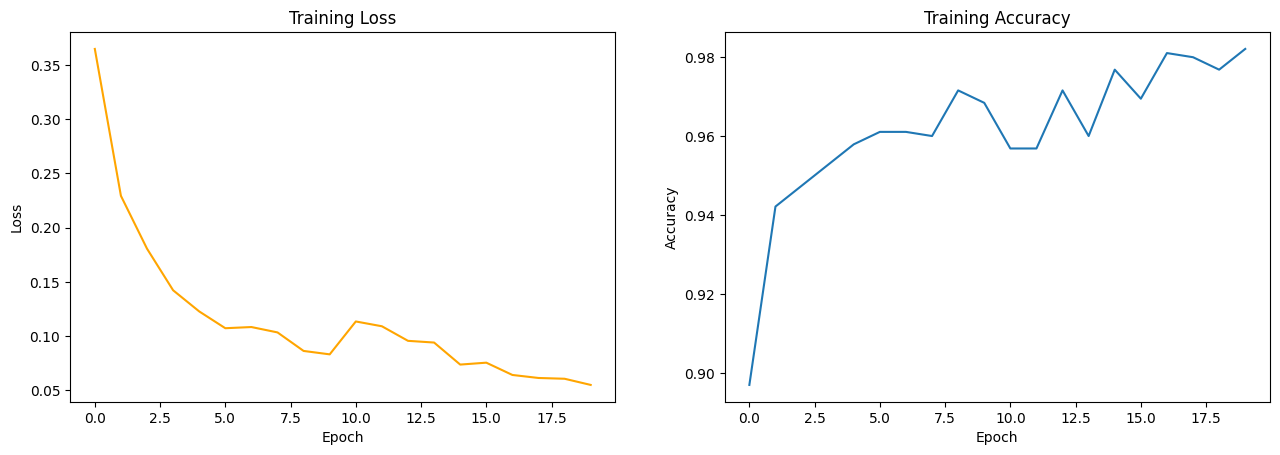

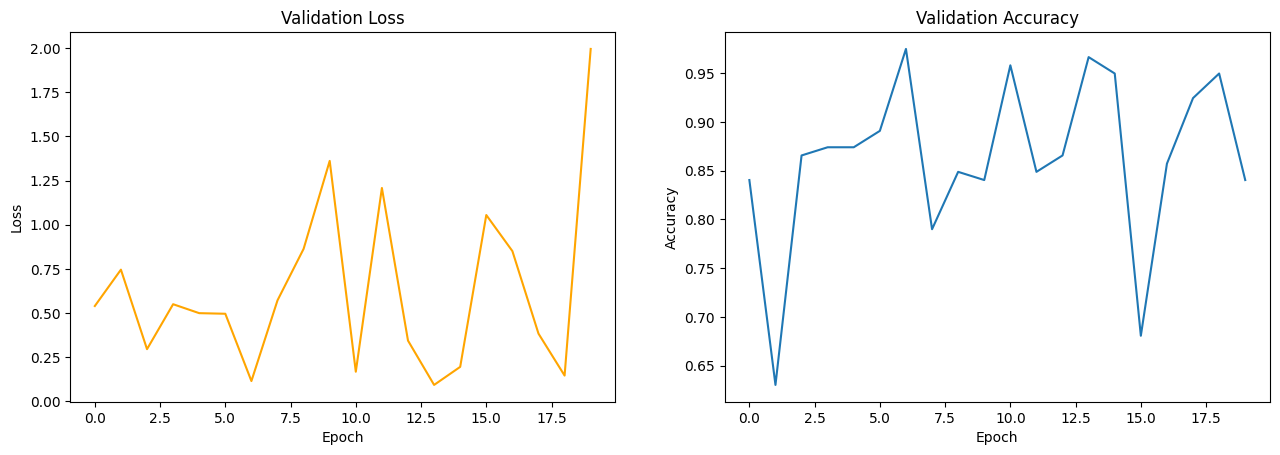

In [ ]:
'''
Plots the training and validation loss/accuracy obtained during training
Training graphs are used to visualize the loss and accuracy during training
Validation graphs can help to determine signs of underfitting/overfitting
'''

train_acc_list = [v.cpu() for v in train_acc_list]
val_acc_list = [v.cpu() for v in val_acc_list]

train_fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(train_loss_list, "orange")
ax2.plot(train_acc_list)
_ = ax1.set_title("Training Loss")
_ = ax2.set_title("Training Accuracy")
_ = ax1.set_xlabel("Epoch")
_ = ax1.set_ylabel("Loss")
_ = ax2.set_xlabel("Epoch")
_ = ax2.set_ylabel("Accuracy")
plt.subplots_adjust(right=2)

val_fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(val_loss_list, "orange")
ax2.plot(val_acc_list)
_ = ax1.set_title("Validation Loss")
_ = ax2.set_title("Validation Accuracy")
_ = ax1.set_xlabel("Epoch")
_ = ax1.set_ylabel("Loss")
_ = ax2.set_xlabel("Epoch")
_ = ax2.set_ylabel("Accuracy")
plt.subplots_adjust(right=2)

In [ ]:
def evaluate(dataloader):
    '''
    Takes in a dataloader and calculates the accuracy (%), F1 and F2 scores
    '''
    model.eval()
    tp = 0
    tn = 0
    fp = 0
    fn = 0

    with torch.no_grad(): # Ensures that weights do not accidentally get updated
        for images, labels in dataloader: # Iterates through the dataloader, and accumulatively calculates tp,tn,fp,fn
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            tp += sum((p == t == 1) for p,t in zip(predicted, labels))
            tn += sum((p == t == 0) for p,t in zip(predicted, labels))
            fp += sum(((p == 1) & (t == 0)) for p,t in zip(predicted, labels))
            fn += sum(((p == 0) & (t == 1)) for p,t in zip(predicted, labels))

    precision = tp/(tp+fp)
    recall = tp/(tp+fn)

    acc = (tp+tn)/len(dataloader.dataset)
    f1_score = 2*((precision*recall)/(precision+recall))
    f2_score = 5*((precision*recall)/(4*precision+recall))
    
    return acc*100, f1_score, f2_score

train_acc, train_f1, train_f2 = evaluate(train_dataloader)
val_acc, val_f1, val_f2 = evaluate(validation_dataloader)
test_acc, test_f1, test_f2 = evaluate(test_dataloader)
print(f"Train Accuracy: {train_acc:.2f}% | Train F1_Score: {train_f1:.2f} | Train F2_Score: {train_f2:.2f}")
print(f"Validation Accuracy: {val_acc:.2f}% | Validation F1_Score: {val_f1:.2f} | Validation F2_Score: {val_f2:.2f}")
print(f"Test Accuracy: {test_acc:.2f}% | Test F1_Score: {test_f1:.2f} | Test F2_Score: {test_f2:.2f}")

Train Accuracy: 84.24% | Train F1_Score: 0.03 | Train F2_Score: 0.02
Validation Accuracy: 84.03% | Validation F1_Score: nan | Validation F2_Score: nan
Test Accuracy: 84.87% | Test F1_Score: 0.10 | Test F2_Score: 0.06
